In [9]:
# ============================================================
# CELL 0 — SETUP + DATA LOAD + DERIVED VARIABLES
# ============================================================


import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# ---------- Style ----------
sns.set_theme(style="whitegrid", font_scale=1.05)
BLUE = "#4C9BE8"
ORANGE = "#E8714C"
RED = "#D94F3D"
GREEN = "#5BA85A"
GREY = "#888888"

os.makedirs("oop_outputs", exist_ok=True)

# ---------- Load ----------
df = pd.read_csv("preprocessed_data.csv", low_memory=False)

print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

# ---------- Numeric coercion ----------
num_cols = [
    "age", "household_size", "monthly_food_spend", "monthly_edu_spend",
    "op_oope_total", "ip_oope_total", "net_oope_op", "net_oope_ip",
    "net_oope_total", "total_hh_spend", "oope_share_income",
    "catastrophic_10", "district_uhc_index", "op_private", "ip_private",
    "had_op_visit", "had_ip_visit", "had_any_visit", "log_net_oope_total"
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ---------- Core derived variables ----------
df["is_insured"] = (df["has_insurance"] == "Have Insurance").astype(int)
df["is_urban"] = (df["rural_urban"] == "Urban").astype(int)
df["is_male"] = (df["gender"] == "Male").astype(int)

# Use preprocessed variables where available
df["total_oope"] = df["net_oope_total"]
df["log_total_oope"] = np.log1p(df["total_oope"])

# Consumption/income proxy
df["monthly_consumption_proxy"] = df["total_hh_spend"]
df["annual_consumption_proxy"] = df["monthly_consumption_proxy"] * 12
df["log_consumption"] = np.log1p(df["monthly_consumption_proxy"])
df["wealth_10k"] = df["monthly_consumption_proxy"] / 10000

# Catastrophic expenditure
df["catastrophic"] = df["catastrophic_10"]

# UHC standardization
df["uhc_std"] = (
    df["district_uhc_index"] - df["district_uhc_index"].mean()
) / df["district_uhc_index"].std()

# Health burden proxy
df["poor_health"] = df["physical_health_rating"].isin(
    ["Poor", "Very Poor", "Average"]
).astype(int)

# Visit indicators
df["visited_op"] = (df["had_op_visit"] == 1).astype(int)
df["visited_ip"] = (df["had_ip_visit"] == 1).astype(int)

print("\nDerived variables created.")
print(df[[
    "total_oope", "total_hh_spend", "catastrophic",
    "is_insured", "op_private", "ip_private",
    "district_uhc_index"
]].describe().round(2))

Data loaded: 40,070 rows × 75 columns

Derived variables created.
       total_oope  total_hh_spend  catastrophic  is_insured  op_private  \
count    40070.00        40070.00      40070.00    40070.00    40070.00   
mean      4805.12         6814.87          0.56        0.27        0.29   
std      31941.66         4292.67          0.50        0.45        0.45   
min         -1.00          250.00          0.00        0.00        0.00   
25%        200.00         4200.00          0.00        0.00        0.00   
50%        850.00         6000.00          1.00        0.00        0.00   
75%       3040.00         8500.00          1.00        1.00        1.00   
max    5035200.00       190000.00          1.00        1.00        1.00   

       ip_private  district_uhc_index  
count     40070.0            36886.00  
mean          0.1               44.69  
std           0.3                7.06  
min           0.0               30.68  
25%           0.0               40.18  
50%           0.0 

RQ1/RQ2: INSURANCE AND OOP EXPENDITURE

Descriptive statistics by insurance status:
                    N     Mean  Median       Std
has_insurance                                   
Have Insurance   9930  5002.47  1020.0  54405.46
No              26955  4895.08   810.0  20069.58

Mann-Whitney U test:
Insured mean: ₹5,002, median: ₹1,020
Uninsured mean: ₹4,895, median: ₹810
U-statistic: 137,599,589
p-value: 0.0000

Controlled OLS model:
                            OLS Regression Results                            
Dep. Variable:         log_total_oope   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                     1228.
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        15:49:08   Log-Likelihood:                -74663.
No. Observations:               36885   AIC:                         1.494e+05
Df Resi

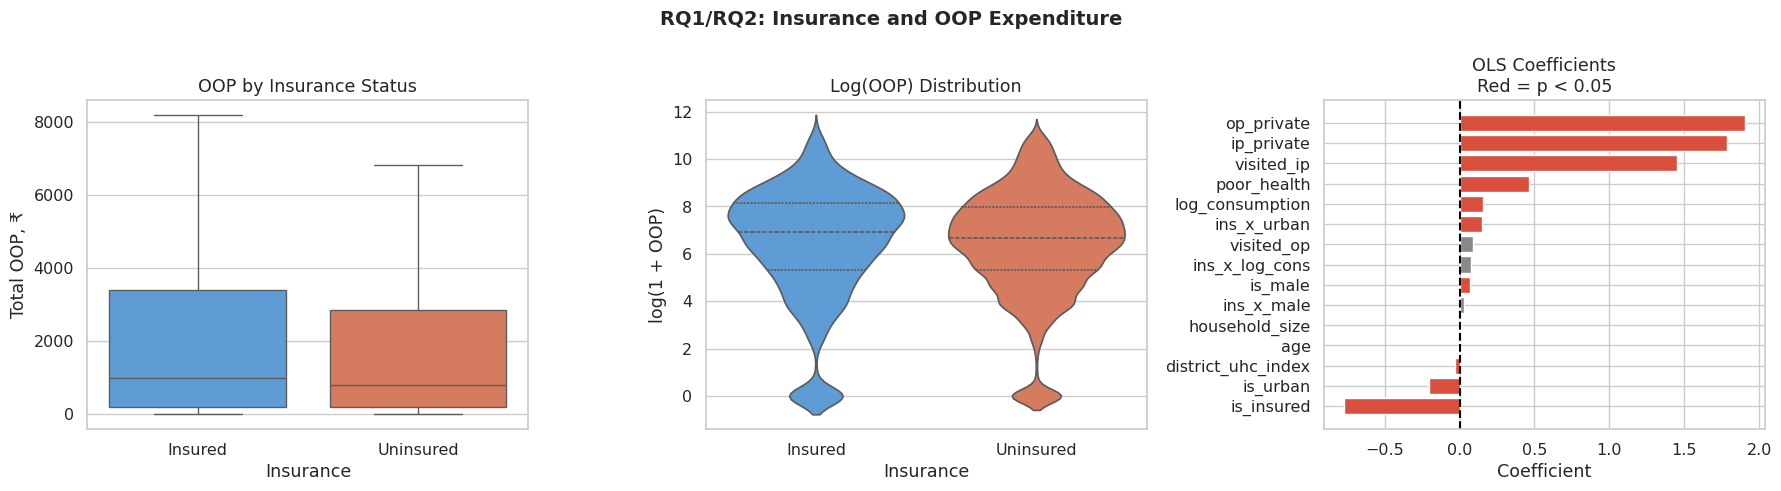


INTERPRETATION:
- is_insured tests whether insurance reduces OOP after controls.
- ins_x_urban tests whether the insurance effect differs in urban areas.
- ins_x_male tests whether the insurance effect differs by gender.
- ins_x_log_cons tests whether insurance works differently by consumption level.



In [10]:
# ============================================================
# CELL 1 — RQ1 + RQ2
# Does insurance reduce OOP?
# Does this effect differ across demographics?
# ============================================================

print("=" * 75)
print("RQ1/RQ2: INSURANCE AND OOP EXPENDITURE")
print("=" * 75)

q1 = df[[
    "total_oope", "log_total_oope", "is_insured", "has_insurance",
    "age", "household_size", "is_urban", "is_male",
    "log_consumption", "poor_health", "visited_op", "visited_ip",
    "op_private", "ip_private", "district_uhc_index",
    "education", "occupation", "caste", "religion"
]].replace([np.inf, -np.inf], np.nan).dropna()

print("\nDescriptive statistics by insurance status:")
desc = q1.groupby("has_insurance")["total_oope"].agg(
    N="count", Mean="mean", Median="median", Std="std"
).round(2)
print(desc)

insured = q1.loc[q1["is_insured"] == 1, "total_oope"]
uninsured = q1.loc[q1["is_insured"] == 0, "total_oope"]

u_stat, p_val = stats.mannwhitneyu(insured, uninsured, alternative="two-sided")
print("\nMann-Whitney U test:")
print(f"Insured mean: ₹{insured.mean():,.0f}, median: ₹{insured.median():,.0f}")
print(f"Uninsured mean: ₹{uninsured.mean():,.0f}, median: ₹{uninsured.median():,.0f}")
print(f"U-statistic: {u_stat:,.0f}")
print(f"p-value: {p_val:.4f}")

# Interaction terms
q1["ins_x_urban"] = q1["is_insured"] * q1["is_urban"]
q1["ins_x_male"] = q1["is_insured"] * q1["is_male"]
q1["ins_x_log_cons"] = q1["is_insured"] * q1["log_consumption"]

formula_q1 = """
log_total_oope ~ is_insured + log_consumption + age + household_size
+ is_urban + is_male + poor_health + visited_op + visited_ip
+ op_private + ip_private + district_uhc_index
+ ins_x_urban + ins_x_male + ins_x_log_cons
+ C(education) + C(occupation)
"""

model_q1 = smf.ols(formula_q1, data=q1).fit(cov_type="HC3")

print("\nControlled OLS model:")
print(model_q1.summary())

key_vars = [
    "is_insured", "log_consumption", "age", "household_size",
    "is_urban", "is_male", "poor_health", "visited_op", "visited_ip",
    "op_private", "ip_private", "district_uhc_index",
    "ins_x_urban", "ins_x_male", "ins_x_log_cons"
]

q1_results = pd.DataFrame({
    "Coefficient": model_q1.params[key_vars],
    "Std Error": model_q1.bse[key_vars],
    "p-value": model_q1.pvalues[key_vars],
    "% Effect": (np.exp(model_q1.params[key_vars]) - 1) * 100
}).round(4)

print("\nKey coefficient table:")
print(q1_results)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RQ1/RQ2: Insurance and OOP Expenditure", fontsize=14, fontweight="bold")

plot_df = q1[q1["total_oope"] <= q1["total_oope"].quantile(0.99)].copy()
plot_df["Insurance"] = plot_df["is_insured"].map({0: "Uninsured", 1: "Insured"})

sns.boxplot(
    data=plot_df, x="Insurance", y="total_oope",
    palette={"Uninsured": ORANGE, "Insured": BLUE},
    showfliers=False, ax=axes[0]
)
axes[0].set_title("OOP by Insurance Status")
axes[0].set_ylabel("Total OOP, ₹")

sns.violinplot(
    data=plot_df, x="Insurance", y="log_total_oope",
    palette={"Uninsured": ORANGE, "Insured": BLUE},
    inner="quartile", ax=axes[1]
)
axes[1].set_title("Log(OOP) Distribution")
axes[1].set_ylabel("log(1 + OOP)")

coef_plot = q1_results.reset_index().rename(columns={"index": "Variable"})
coef_plot = coef_plot.sort_values("Coefficient")
axes[2].barh(
    coef_plot["Variable"], coef_plot["Coefficient"],
    color=[RED if p < 0.05 else GREY for p in coef_plot["p-value"]]
)
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("OLS Coefficients\nRed = p < 0.05")
axes[2].set_xlabel("Coefficient")

plt.tight_layout()
plt.savefig("oop_outputs/rq1_rq2_insurance.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
INTERPRETATION:
- is_insured tests whether insurance reduces OOP after controls.
- ins_x_urban tests whether the insurance effect differs in urban areas.
- ins_x_male tests whether the insurance effect differs by gender.
- ins_x_log_cons tests whether insurance works differently by consumption level.
""")

RQ3: PUBLIC VS PRIVATE HEALTHCARE EXPENDITURE

Outpatient descriptive statistics:
                N     Mean  Median      Std
op_private                                 
Public      24394   719.35   240.0  1709.23
Private     10218  4065.45  1830.0  9018.56
Welch test: private-public difference = ₹3,346, p=0.0000
Controlled private premium: +932.44% | p=0.0000 | R²=0.2608

Inpatient descriptive statistics:
                N      Mean   Median       Std
ip_private                                    
Public      14386   1823.74    590.0   5671.67
Private      3680  26609.69  10500.0  98027.61
Welch test: private-public difference = ₹24,786, p=0.0000
Controlled private premium: +2719.12% | p=0.0000 | R²=0.3095

Private × Inpatient interaction model:
                            OLS Regression Results                            
Dep. Variable:               log_oope   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.288
Method

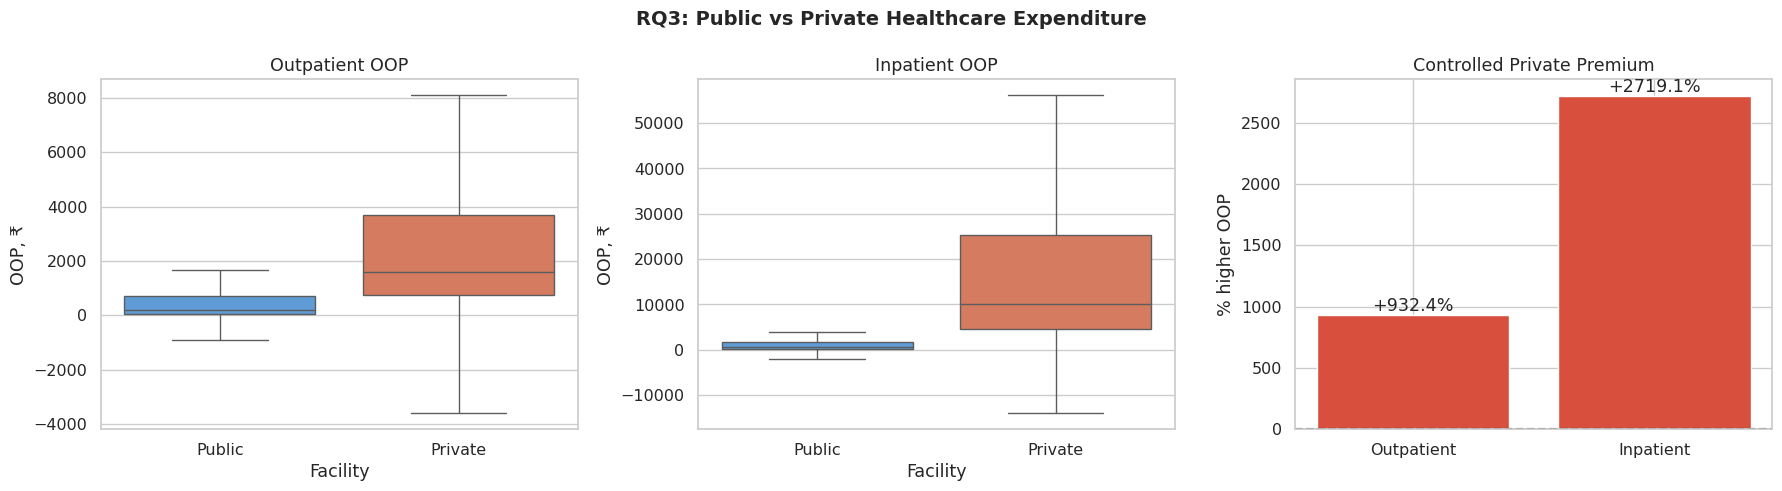


INTERPRETATION:
- private coefficient > 0 means private care is more expensive than public care.
- private_x_ip > 0 means the private-sector premium is larger for inpatient care than outpatient care.



In [11]:
# ============================================================
# CELL 2 — RQ3
# Are private hospitals/facilities significantly more expensive?
# Does the gap differ between OP and IP care?
# ============================================================

print("=" * 75)
print("RQ3: PUBLIC VS PRIVATE HEALTHCARE EXPENDITURE")
print("=" * 75)

results_q3 = {}

for care, oop_col, private_col, illness_col in [
    ("Outpatient", "net_oope_op", "op_private", "op_illness_category"),
    ("Inpatient", "net_oope_ip", "ip_private", "ip_illness_category")
]:
    sub = df[[
        oop_col, private_col, "age", "household_size",
        "rural_urban", "has_insurance", "district_uhc_tercile",
        illness_col
    ]].replace([np.inf, -np.inf], np.nan).dropna().copy()

    sub = sub[sub[oop_col] >= 0]
    sub["log_oope"] = np.log1p(sub[oop_col])

    print(f"\n{care} descriptive statistics:")
    print(
        sub.groupby(private_col)[oop_col]
        .agg(N="count", Mean="mean", Median="median", Std="std")
        .rename(index={0: "Public", 1: "Private"})
        .round(2)
    )

    public = sub.loc[sub[private_col] == 0, oop_col]
    private = sub.loc[sub[private_col] == 1, oop_col]

    t_stat, p_val = stats.ttest_ind(private, public, equal_var=False)
    print(f"Welch test: private-public difference = ₹{private.mean() - public.mean():,.0f}, p={p_val:.4f}")

    formula = f"""
    log_oope ~ {private_col} + age + household_size
    + C(rural_urban) + C(has_insurance)
    + C(district_uhc_tercile) + C({illness_col})
    """

    model = smf.ols(formula, data=sub).fit(cov_type="HC3")

    coef = model.params[private_col]
    p = model.pvalues[private_col]
    pct = (np.exp(coef) - 1) * 100

    results_q3[care] = {
        "coef": coef,
        "p": p,
        "pct": pct,
        "r2": model.rsquared
    }

    print(f"Controlled private premium: {pct:+.2f}% | p={p:.4f} | R²={model.rsquared:.4f}")

# OP/IP stacked interaction
op = df[[
    "net_oope_op", "op_private", "age", "household_size",
    "rural_urban", "has_insurance", "district_uhc_tercile"
]].dropna().copy()
op = op.rename(columns={"net_oope_op": "oope", "op_private": "private"})
op["episode_ip"] = 0

ip = df[[
    "net_oope_ip", "ip_private", "age", "household_size",
    "rural_urban", "has_insurance", "district_uhc_tercile"
]].dropna().copy()
ip = ip.rename(columns={"net_oope_ip": "oope", "ip_private": "private"})
ip["episode_ip"] = 1

stacked = pd.concat([op, ip], ignore_index=True)
stacked = stacked[stacked["oope"] >= 0].copy()
stacked["log_oope"] = np.log1p(stacked["oope"])
stacked["private_x_ip"] = stacked["private"] * stacked["episode_ip"]

model_private_episode = smf.ols(
    """
    log_oope ~ private + episode_ip + private_x_ip
    + age + household_size + C(rural_urban)
    + C(has_insurance) + C(district_uhc_tercile)
    """,
    data=stacked
).fit(cov_type="HC3")

print("\nPrivate × Inpatient interaction model:")
print(model_private_episode.summary())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RQ3: Public vs Private Healthcare Expenditure", fontsize=14, fontweight="bold")

for ax, care, oop_col, private_col in [
    (axes[0], "Outpatient", "net_oope_op", "op_private"),
    (axes[1], "Inpatient", "net_oope_ip", "ip_private")
]:
    sub = df[[oop_col, private_col]].dropna()
    sub = sub[sub[oop_col] <= sub[oop_col].quantile(0.99)].copy()
    sub["Facility"] = sub[private_col].map({0: "Public", 1: "Private"})

    sns.boxplot(
        data=sub, x="Facility", y=oop_col,
        palette={"Public": BLUE, "Private": ORANGE},
        showfliers=False, ax=ax
    )
    ax.set_title(f"{care} OOP")
    ax.set_ylabel("OOP, ₹")

labels = list(results_q3.keys())
premiums = [results_q3[x]["pct"] for x in labels]
pvals = [results_q3[x]["p"] for x in labels]

axes[2].bar(labels, premiums, color=[RED if p < 0.05 else GREY for p in pvals])
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set_title("Controlled Private Premium")
axes[2].set_ylabel("% higher OOP")

for i, val in enumerate(premiums):
    axes[2].text(i, val, f"{val:+.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("oop_outputs/rq3_public_private.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
INTERPRETATION:
- private coefficient > 0 means private care is more expensive than public care.
- private_x_ip > 0 means the private-sector premium is larger for inpatient care than outpatient care.
""")

RQ4/RQ5: CATASTROPHIC EXPENDITURE AND SPLINE THRESHOLD
Valid observations: 36,885
Overall catastrophic rate: 56.87%

Catastrophic rate by income quintile:
                   Rate  Affected  Total  Rate (%)
income_quintile2                                  
Q1 Poorest        0.620      5583   9001    62.026
Q2                0.587      3581   6096    58.743
Q3                0.577      4060   7037    57.695
Q4                0.555      4423   7976    55.454
Q5 Richest        0.492      3331   6775    49.166

Spline knots:
P25: ₹4,200/month
P50: ₹6,000/month
P75: ₹8,200/month

OLS spline for OOP share:
                            OLS Regression Results                            
Dep. Variable:      oope_share_income   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     64.89
Date:                Fri, 01 May 2026   Prob (F-statistic):           8.84e-

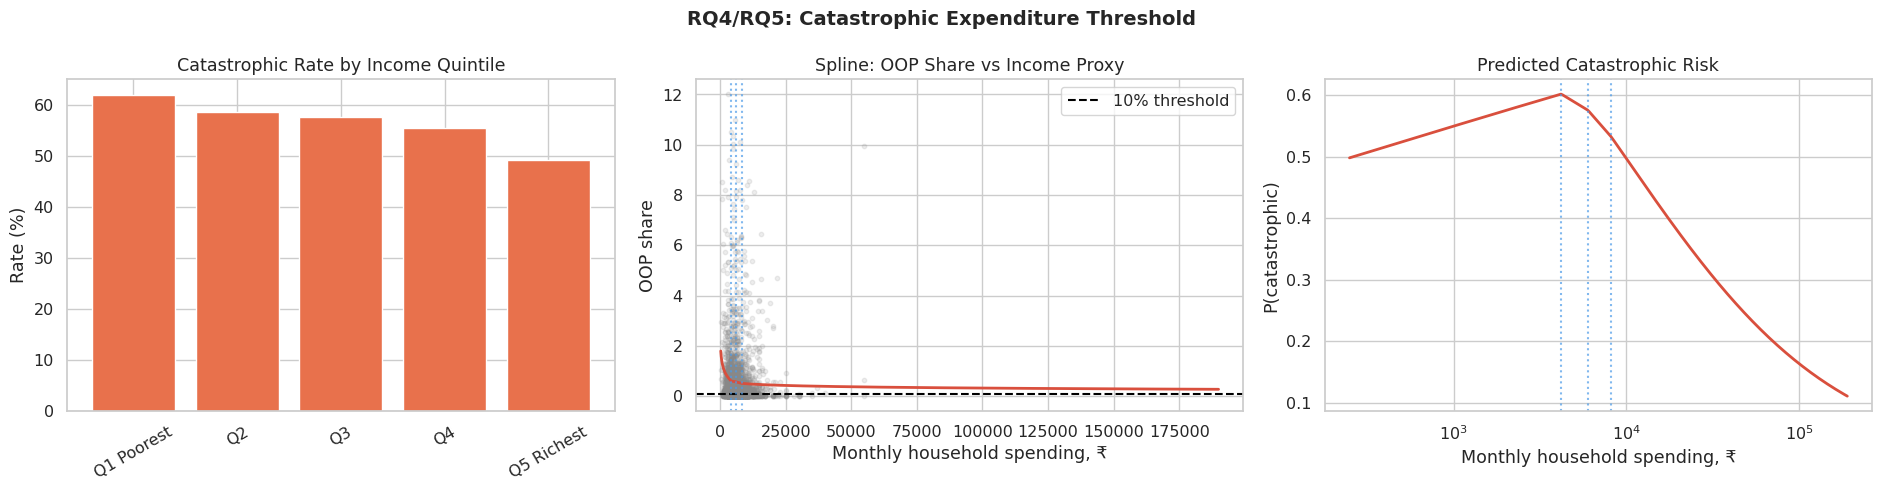


INTERPRETATION:
- Catastrophic expenditure is OOP > 10% of household spending.
- Quintiles show whether poorer households face higher catastrophic burden.
- Spline knots identify income ranges where the OOP burden-risk relationship changes.



In [12]:
# ============================================================
# CELL 3 — RQ4 + RQ5
# At what income level does expenditure become catastrophic?
# Can spline model detect threshold?
# ============================================================

print("=" * 75)
print("RQ4/RQ5: CATASTROPHIC EXPENDITURE AND SPLINE THRESHOLD")
print("=" * 75)

cat = df[[
    "catastrophic", "total_oope", "total_hh_spend",
    "oope_share_income", "is_insured", "is_urban",
    "district_uhc_index", "age", "household_size"
]].replace([np.inf, -np.inf], np.nan).dropna().copy()

cat = cat[(cat["total_hh_spend"] > 0) & (cat["total_oope"] >= 0)]

print(f"Valid observations: {len(cat):,}")
print(f"Overall catastrophic rate: {cat['catastrophic'].mean() * 100:.2f}%")

cat["income_quintile2"] = pd.qcut(
    cat["total_hh_spend"],
    q=5,
    labels=["Q1 Poorest", "Q2", "Q3", "Q4", "Q5 Richest"],
    duplicates="drop"
)

cat_by_q = cat.groupby("income_quintile2")["catastrophic"].agg(
    Rate="mean", Affected="sum", Total="count"
)
cat_by_q["Rate (%)"] = cat_by_q["Rate"] * 100

print("\nCatastrophic rate by income quintile:")
print(cat_by_q.round(3))

# Spline model
spline_df = cat.copy()
spline_df = spline_df[
    spline_df["oope_share_income"] <= spline_df["oope_share_income"].quantile(0.99)
].copy()

spline_df["log_income"] = np.log(spline_df["total_hh_spend"])

knots_log = spline_df["log_income"].quantile([0.25, 0.50, 0.75]).values
knots_rs = np.exp(knots_log)

print("\nSpline knots:")
for pct, k in zip([25, 50, 75], knots_rs):
    print(f"P{pct}: ₹{k:,.0f}/month")

for i, k in enumerate(knots_log, 1):
    spline_df[f"knot_{i}"] = np.maximum(0, spline_df["log_income"] - k)

spline_ols = smf.ols(
    "oope_share_income ~ log_income + knot_1 + knot_2 + knot_3",
    data=spline_df
).fit(cov_type="HC3")

print("\nOLS spline for OOP share:")
print(spline_ols.summary())

logit_spline = smf.logit(
    """
    catastrophic ~ log_income + knot_1 + knot_2 + knot_3
    + is_insured + is_urban + district_uhc_index
    """,
    data=spline_df
).fit(disp=False, method="lbfgs")

print("\nLogistic spline for catastrophic expenditure:")
print(logit_spline.summary())

or_spline = pd.DataFrame({
    "OR": np.exp(logit_spline.params),
    "p-value": logit_spline.pvalues
}).round(4)

print("\nOdds ratios:")
print(or_spline)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle("RQ4/RQ5: Catastrophic Expenditure Threshold", fontsize=14, fontweight="bold")

axes[0].bar(cat_by_q.index.astype(str), cat_by_q["Rate (%)"], color=ORANGE)
axes[0].set_title("Catastrophic Rate by Income Quintile")
axes[0].set_ylabel("Rate (%)")
axes[0].tick_params(axis="x", rotation=30)

sample = spline_df.sample(min(3000, len(spline_df)), random_state=42)
axes[1].scatter(
    sample["total_hh_spend"], sample["oope_share_income"],
    alpha=0.15, s=10, color=GREY
)

x_grid = np.linspace(spline_df["log_income"].min(), spline_df["log_income"].max(), 300)
pred_df = pd.DataFrame({"log_income": x_grid})
for i, k in enumerate(knots_log, 1):
    pred_df[f"knot_{i}"] = np.maximum(0, pred_df["log_income"] - k)

y_pred = spline_ols.predict(pred_df)
axes[1].plot(np.exp(x_grid), y_pred, color=RED, linewidth=2)
axes[1].axhline(0.10, color="black", linestyle="--", label="10% threshold")
for k in knots_rs:
    axes[1].axvline(k, color=BLUE, linestyle=":", alpha=0.7)
axes[1].set_title("Spline: OOP Share vs Income Proxy")
axes[1].set_xlabel("Monthly household spending, ₹")
axes[1].set_ylabel("OOP share")
axes[1].legend()

pred_logit = pred_df.copy()
pred_logit["is_insured"] = 0
pred_logit["is_urban"] = spline_df["is_urban"].median()
pred_logit["district_uhc_index"] = spline_df["district_uhc_index"].median()

prob = logit_spline.predict(pred_logit)
axes[2].plot(np.exp(x_grid), prob, color=RED, linewidth=2)
axes[2].set_xscale("log")
axes[2].set_title("Predicted Catastrophic Risk")
axes[2].set_xlabel("Monthly household spending, ₹")
axes[2].set_ylabel("P(catastrophic)")
for k in knots_rs:
    axes[2].axvline(k, color=BLUE, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.savefig("oop_outputs/rq4_rq5_spline_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
INTERPRETATION:
- Catastrophic expenditure is OOP > 10% of household spending.
- Quintiles show whether poorer households face higher catastrophic burden.
- Spline knots identify income ranges where the OOP burden-risk relationship changes.
""")

RQ6/RQ9: DISTRICT EFFECTS AND HEALTH INFRASTRUCTURE PROXY
District correlation: UHC index vs catastrophic rate
r = -0.2193, p = 0.0191

Controlled logistic model for catastrophic expenditure:
                           Logit Regression Results                           
Dep. Variable:           catastrophic   No. Observations:                36885
Model:                          Logit   Df Residuals:                    36876
Method:                           MLE   Df Model:                            8
Date:                Fri, 01 May 2026   Pseudo R-squ.:                  0.1858
Time:                        15:49:15   Log-Likelihood:                -20533.
converged:                      False   LL-Null:                       -25217.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept 

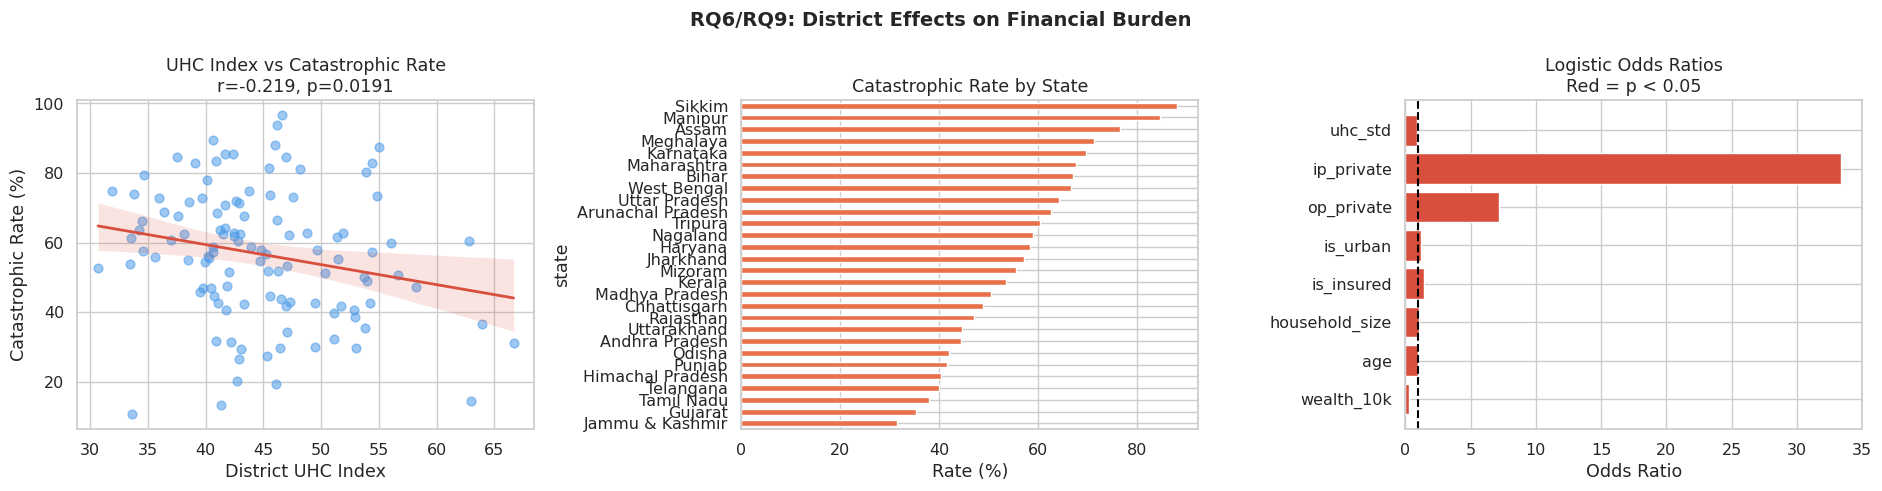


INTERPRETATION:
- district_uhc_index is used as a proxy for district-level healthcare infrastructure and UHC performance.
- Direct PHC density/specialist availability variables are not present in this dataset.
- uhc_std tests whether better district health-system performance predicts lower OOP/catastrophic risk after controls.
- Mixed model estimates whether district identity itself explains meaningful variation.



In [13]:
# ============================================================
# CELL 4 — RQ6 + RQ9
# Do districts amplify/reduce financial burden?
# Does district UHC infrastructure proxy matter after controls?
# ============================================================

print("=" * 75)
print("RQ6/RQ9: DISTRICT EFFECTS AND HEALTH INFRASTRUCTURE PROXY")
print("=" * 75)

dist = df[[
    "district", "state", "district_uhc_index", "district_uhc_tercile",
    "uhc_std", "catastrophic", "total_oope", "log_total_oope",
    "is_insured", "is_urban", "age", "household_size",
    "wealth_10k", "op_private", "ip_private"
]].replace([np.inf, -np.inf], np.nan).dropna().copy()

# District-level aggregation
dist_agg = dist.groupby("district").agg(
    cat_rate=("catastrophic", "mean"),
    mean_oop=("total_oope", "mean"),
    uhc_index=("district_uhc_index", "first"),
    n=("catastrophic", "count")
).reset_index()

dist_agg = dist_agg[dist_agg["n"] >= 30]
dist_agg["cat_rate_pct"] = dist_agg["cat_rate"] * 100

r, p = stats.pearsonr(dist_agg["uhc_index"], dist_agg["cat_rate"])
print(f"District correlation: UHC index vs catastrophic rate")
print(f"r = {r:.4f}, p = {p:.4f}")

# Logistic model: catastrophic risk
model_dist_logit = smf.logit(
    """
    catastrophic ~ wealth_10k + age + household_size
    + is_insured + is_urban + op_private + ip_private + uhc_std
    """,
    data=dist
).fit(disp=False, method="lbfgs")

print("\nControlled logistic model for catastrophic expenditure:")
print(model_dist_logit.summary())

or_dist = pd.DataFrame({
    "OR": np.exp(model_dist_logit.params),
    "p-value": model_dist_logit.pvalues
}).round(4)

print("\nOdds ratios:")
print(or_dist)

# OLS model: log OOP
model_dist_ols = smf.ols(
    """
    log_total_oope ~ uhc_std + is_insured + is_urban
    + wealth_10k + age + household_size + op_private + ip_private
    """,
    data=dist
).fit(cov_type="HC3")

print("\nControlled OLS model for log OOP:")
print(model_dist_ols.summary())

# Insurance × district UHC interaction
model_dist_interaction = smf.ols(
    """
    log_total_oope ~ uhc_std * is_insured + is_urban
    + wealth_10k + age + household_size + op_private + ip_private
    """,
    data=dist
).fit(cov_type="HC3")

print("\nInsurance × UHC interaction model:")
print(model_dist_interaction.summary())

# Multilevel model
try:
    mixed = smf.mixedlm(
        """
        log_total_oope ~ uhc_std + is_insured + is_urban
        + wealth_10k + age + household_size
        """,
        data=dist,
        groups=dist["district"]
    ).fit(method="lbfgs", disp=False)

    print("\nRandom-intercept district model:")
    print(mixed.summary())

    var_between = float(mixed.cov_re.iloc[0, 0])
    var_within = float(mixed.scale)
    icc = var_between / (var_between + var_within)
    print(f"\nApproximate ICC: {icc:.3f} ({icc*100:.1f}% variation between districts)")

except Exception as e:
    print("\nMixed model skipped due to convergence issue:")
    print(e)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle("RQ6/RQ9: District Effects on Financial Burden", fontsize=14, fontweight="bold")

sns.regplot(
    data=dist_agg, x="uhc_index", y="cat_rate_pct",
    scatter_kws={"alpha": 0.55, "s": 40, "color": BLUE},
    line_kws={"color": RED, "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title(f"UHC Index vs Catastrophic Rate\nr={r:.3f}, p={p:.4f}")
axes[0].set_xlabel("District UHC Index")
axes[0].set_ylabel("Catastrophic Rate (%)")

state_rates = dist.groupby("state")["catastrophic"].mean().sort_values() * 100
state_rates.plot(kind="barh", ax=axes[1], color=ORANGE)
axes[1].set_title("Catastrophic Rate by State")
axes[1].set_xlabel("Rate (%)")

or_plot = or_dist.drop("Intercept", errors="ignore").reset_index()
or_plot.columns = ["Variable", "OR", "p-value"]
axes[2].barh(
    or_plot["Variable"], or_plot["OR"],
    color=[RED if x < 0.05 else GREY for x in or_plot["p-value"]]
)
axes[2].axvline(1, color="black", linestyle="--")
axes[2].set_title("Logistic Odds Ratios\nRed = p < 0.05")
axes[2].set_xlabel("Odds Ratio")

plt.tight_layout()
plt.savefig("oop_outputs/rq6_rq9_district_effects.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
INTERPRETATION:
- district_uhc_index is used as a proxy for district-level healthcare infrastructure and UHC performance.
- Direct PHC density/specialist availability variables are not present in this dataset.
- uhc_std tests whether better district health-system performance predicts lower OOP/catastrophic risk after controls.
- Mixed model estimates whether district identity itself explains meaningful variation.
""")

RQ7: LASSO FOR NON-OBVIOUS PREDICTORS OF CATASTROPHIC EXPENDITURE
LASSO dataset size: 1,921 rows
Numeric features: ['age', 'household_size', 'total_hh_spend', 'district_uhc_index', 'is_insured', 'is_urban', 'is_male', 'op_private', 'ip_private', 'poor_health', 'had_op_visit', 'had_ip_visit', 'ins_premium_annual', 'ins_coverage_limit']
Categorical features: ['education', 'occupation', 'religion', 'caste', 'marital_status', 'physical_health_rating', 'mental_health_rating', 'district_uhc_tercile', 'state_region']

Test ROC-AUC: 0.840

Classification report:
              precision    recall  f1-score   support

           0       0.58      0.76      0.66       147
           1       0.88      0.76      0.82       334

    accuracy                           0.76       481
   macro avg       0.73      0.76      0.74       481
weighted avg       0.79      0.76      0.77       481

Confusion matrix:
[[111  36]
 [ 79 255]]

Top selected predictors:
                           feature    coef  a

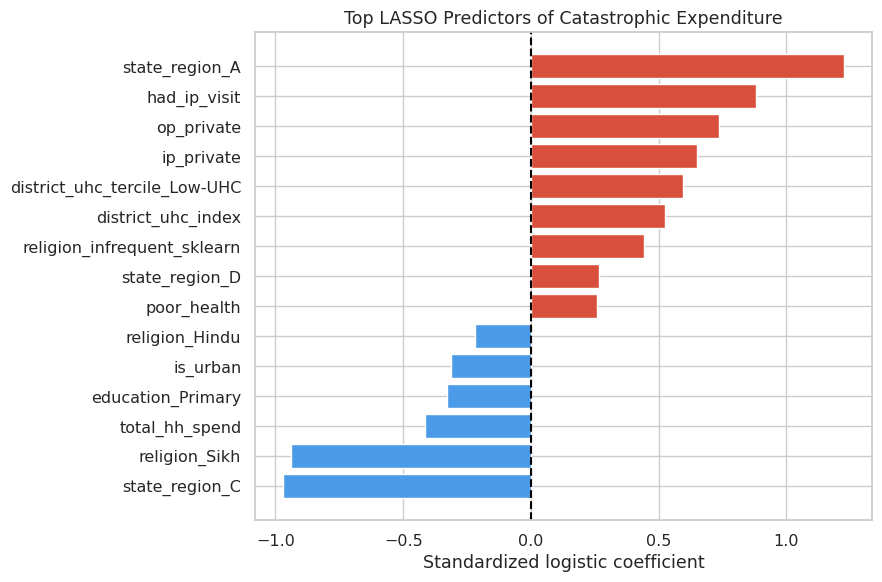


INTERPRETATION:
- Positive coefficients increase predicted catastrophic-expenditure risk.
- Negative coefficients are protective.
- Treat this as predictor discovery, not causal evidence.
- Since OOP variables are excluded, this identifies policy-relevant predictors instead of mechanical predictors.



In [14]:
# ============================================================
# CELL 5 — RQ7
# Can regularization identify non-obvious predictors
# of catastrophic expenditure?
# ============================================================

print("=" * 75)
print("RQ7: LASSO FOR NON-OBVIOUS PREDICTORS OF CATASTROPHIC EXPENDITURE")
print("=" * 75)

# Policy-driver mode avoids leakage by excluding OOP variables,
# because OOP mechanically defines catastrophic expenditure.
numeric_features = [
    "age", "household_size", "total_hh_spend",
    "district_uhc_index", "is_insured", "is_urban",
    "is_male", "op_private", "ip_private", "poor_health",
    "had_op_visit", "had_ip_visit", "ins_premium_annual",
    "ins_coverage_limit"
]

categorical_features = [
    "education", "occupation", "religion", "caste",
    "marital_status", "physical_health_rating",
    "mental_health_rating", "district_uhc_tercile",
    "state_region"
]

numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

lasso_df = df[["catastrophic"] + numeric_features + categorical_features].replace(
    [np.inf, -np.inf], np.nan
).dropna().copy()

print(f"LASSO dataset size: {lasso_df.shape[0]:,} rows")
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X = lasso_df[numeric_features + categorical_features]
y = lasso_df["catastrophic"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), categorical_features)
    ]
)

lasso_model = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty="l1",
    solver="saga",
    scoring="roc_auc",
    max_iter=5000,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", lasso_model)
])

pipe.fit(X_train, y_train)

pred_prob = pipe.predict_proba(X_test)[:, 1]
pred_class = pipe.predict(X_test)

auc = roc_auc_score(y_test, pred_prob)
print(f"\nTest ROC-AUC: {auc:.3f}")
print("\nClassification report:")
print(classification_report(y_test, pred_class))
print("Confusion matrix:")
print(confusion_matrix(y_test, pred_class))

# Extract selected predictors
feature_names_num = numeric_features
feature_names_cat = list(
    pipe.named_steps["preprocess"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

feature_names = feature_names_num + feature_names_cat
coefs = pipe.named_steps["model"].coef_[0]

coef_tbl = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
})

coef_tbl = coef_tbl[coef_tbl["coef"].abs() > 1e-6].copy()
coef_tbl["abs_coef"] = coef_tbl["coef"].abs()
coef_tbl = coef_tbl.sort_values("abs_coef", ascending=False)

print("\nTop selected predictors:")
print(coef_tbl.head(25).round(4))

# Plot
top = coef_tbl.head(15).sort_values("coef")

plt.figure(figsize=(9, 6))
plt.barh(
    top["feature"], top["coef"],
    color=[RED if c > 0 else BLUE for c in top["coef"]]
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Top LASSO Predictors of Catastrophic Expenditure")
plt.xlabel("Standardized logistic coefficient")
plt.tight_layout()
plt.savefig("oop_outputs/rq7_lasso_predictors.png", dpi=150, bbox_inches="tight")
plt.show()

coef_tbl.to_csv("oop_outputs/rq7_lasso_selected_predictors.csv", index=False)

print("""
INTERPRETATION:
- Positive coefficients increase predicted catastrophic-expenditure risk.
- Negative coefficients are protective.
- Treat this as predictor discovery, not causal evidence.
- Since OOP variables are excluded, this identifies policy-relevant predictors instead of mechanical predictors.
""")

RQ8: OUTPATIENT VS INPATIENT OOP GAP

Descriptive statistics:
       net_oope_op  net_oope_ip  ip_minus_op_gap
count     39136.00     19209.00         40070.00
mean       1576.50      6811.56          1725.62
std        5164.48     44548.22         30947.98
min      -29500.00    -22000.00       -191700.00
25%          90.00       200.00          -790.00
50%         450.00      1000.00          -120.00
75%        1400.00      3550.00           160.00
max      307500.00   5031200.00       5027200.00

Paired t-test among households with both OP and IP:
t = 14.664, p = 0.0000
Mean IP-OP gap = ₹4,861

OLS model predicting IP − OP cost gap:
                            OLS Regression Results                            
Dep. Variable:        ip_minus_op_gap   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     56.44
Date:                Fri, 01 May 2026   P

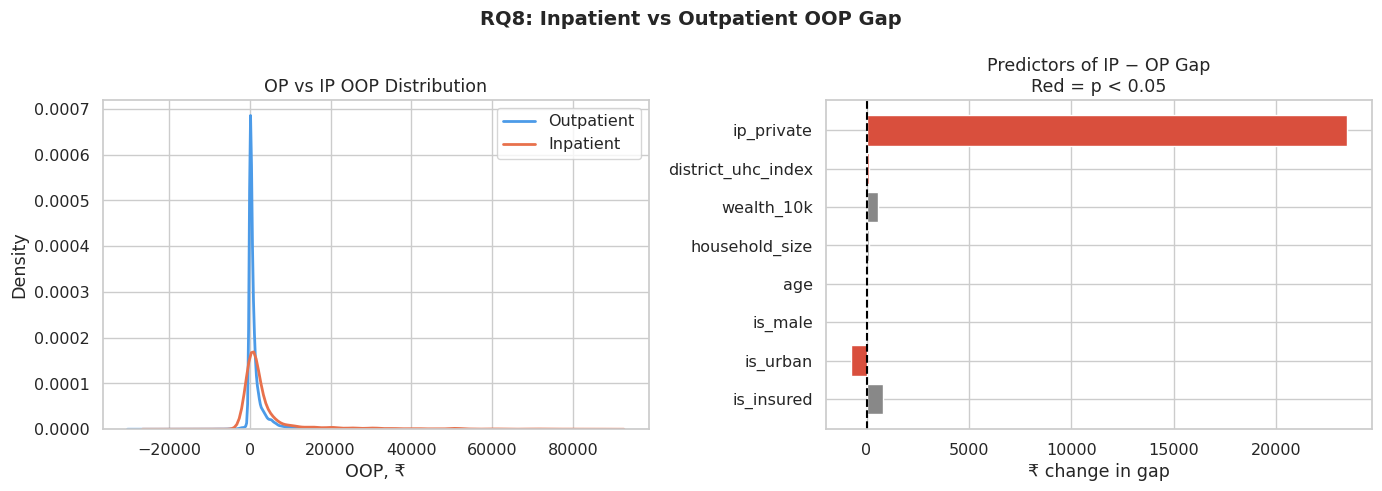


INTERPRETATION:
- Positive coefficients increase the inpatient-over-outpatient expenditure gap.
- ip_private is the most direct test of whether private inpatient care drives the cost shock.



In [15]:
# ============================================================
# CELL 6 — RQ8
# Does the OOP gap vary between outpatient and inpatient care?
# Which demographics predict the IP-OP gap?
# ============================================================

print("=" * 75)
print("RQ8: OUTPATIENT VS INPATIENT OOP GAP")
print("=" * 75)

gap_df = df[[
    "net_oope_op", "net_oope_ip", "is_insured", "is_urban",
    "is_male", "age", "household_size", "wealth_10k",
    "district_uhc_index", "op_private", "ip_private",
    "education", "occupation"
]].replace([np.inf, -np.inf], np.nan).copy()

gap_df["op_oop_zero"] = gap_df["net_oope_op"].fillna(0)
gap_df["ip_oop_zero"] = gap_df["net_oope_ip"].fillna(0)
gap_df["ip_minus_op_gap"] = gap_df["ip_oop_zero"] - gap_df["op_oop_zero"]

print("\nDescriptive statistics:")
print(gap_df[["net_oope_op", "net_oope_ip", "ip_minus_op_gap"]].describe().round(2))

both = gap_df.dropna(subset=["net_oope_op", "net_oope_ip"]).copy()

if len(both) > 10:
    t_stat, p_val = stats.ttest_rel(both["net_oope_ip"], both["net_oope_op"])
    print(f"\nPaired t-test among households with both OP and IP:")
    print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
    print(f"Mean IP-OP gap = ₹{(both['net_oope_ip'] - both['net_oope_op']).mean():,.0f}")

reg_gap = gap_df.dropna(subset=[
    "ip_minus_op_gap", "is_insured", "is_urban", "is_male",
    "age", "household_size", "wealth_10k",
    "district_uhc_index", "ip_private"
]).copy()

model_gap = smf.ols(
    """
    ip_minus_op_gap ~ is_insured + is_urban + is_male
    + age + household_size + wealth_10k
    + district_uhc_index + ip_private
    + C(education) + C(occupation)
    """,
    data=reg_gap
).fit(cov_type="HC3")

print("\nOLS model predicting IP − OP cost gap:")
print(model_gap.summary())

gap_key = [
    "is_insured", "is_urban", "is_male", "age",
    "household_size", "wealth_10k",
    "district_uhc_index", "ip_private"
]

gap_results = pd.DataFrame({
    "Coefficient": model_gap.params[gap_key],
    "Std Error": model_gap.bse[gap_key],
    "p-value": model_gap.pvalues[gap_key]
}).round(3)

print("\nKey gap coefficients:")
print(gap_results)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("RQ8: Inpatient vs Outpatient OOP Gap", fontsize=14, fontweight="bold")

op_vals = gap_df["net_oope_op"].dropna()
ip_vals = gap_df["net_oope_ip"].dropna()

op_vals = op_vals[op_vals <= op_vals.quantile(0.99)]
ip_vals = ip_vals[ip_vals <= ip_vals.quantile(0.99)]

sns.kdeplot(op_vals, ax=axes[0], label="Outpatient", color=BLUE, linewidth=2)
sns.kdeplot(ip_vals, ax=axes[0], label="Inpatient", color=ORANGE, linewidth=2)
axes[0].set_title("OP vs IP OOP Distribution")
axes[0].set_xlabel("OOP, ₹")
axes[0].legend()

coef_plot = gap_results.reset_index().rename(columns={"index": "Variable"})
axes[1].barh(
    coef_plot["Variable"], coef_plot["Coefficient"],
    color=[RED if p < 0.05 else GREY for p in coef_plot["p-value"]]
)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Predictors of IP − OP Gap\nRed = p < 0.05")
axes[1].set_xlabel("₹ change in gap")

plt.tight_layout()
plt.savefig("oop_outputs/rq8_op_ip_gap.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
INTERPRETATION:
- Positive coefficients increase the inpatient-over-outpatient expenditure gap.
- ip_private is the most direct test of whether private inpatient care drives the cost shock.
""")

In [16]:
# ============================================================
# CELL 7 — EXPORT OUTPUTS
# ============================================================

import shutil

summary_cols = [
    "state", "state_region", "district", "rural_urban",
    "age", "gender", "education", "occupation", "caste", "religion",
    "household_size", "has_insurance", "is_insured",
    "total_hh_spend", "total_oope", "net_oope_op", "net_oope_ip",
    "catastrophic", "district_uhc_index", "district_uhc_tercile",
    "op_private", "ip_private"
]

summary_cols = [c for c in summary_cols if c in df.columns]
df[summary_cols].to_csv("oop_outputs/analysis_dataset_summary.csv", index=False)

q1_results.to_csv("oop_outputs/rq1_insurance_results.csv")
q1_model_summary = model_q1.summary().as_text()
with open("oop_outputs/rq1_model_summary.txt", "w") as f:
    f.write(q1_model_summary)

or_spline.to_csv("oop_outputs/rq4_rq5_spline_odds.csv")
or_dist.to_csv("oop_outputs/rq6_rq9_district_odds.csv")
gap_results.to_csv("oop_outputs/rq8_gap_results.csv")

shutil.make_archive("oop_outputs", "zip", "oop_outputs")

print("All outputs saved in oop_outputs/")
print("Zip file created: oop_outputs.zip")

# In Colab, uncomment this to download:
# from google.colab import files
# files.download("oop_outputs.zip")

All outputs saved in oop_outputs/
Zip file created: oop_outputs.zip
